In [ ]:
# Importeer benodigde libraries
import pandas as pd  # Voor data manipulatie
import numpy as np  # Voor numerieke berekeningen
import matplotlib.pyplot as plt  # Voor visualisaties
from sklearn.cluster import KMeans  # KMeans clustering model
from sklearn.preprocessing import StandardScaler  # Voor schalen van data
from sklearn.metrics import silhouette_score  # Voor evaluatie
from sklearn.decomposition import PCA  # Importeer PCA voor veel features tegelijk
from sklearn.metrics import silhouette_samples   # voor silhouette plot


In [3]:
# Lees Excel bestand in
file_path = 'AmesHousing.xlsx'  # Bestandsnaam
df = pd.read_excel(file_path, sheet_name='AmesHousing')  # Lees juiste sheet
df.head()  # Toon eerste rijen

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [4]:
# Functie om experiment uit te voeren
def run_experiment(features, n_clusters, random_state=42, n_init=10):
    data = df[features].copy()  # Selecteer features
    data = pd.get_dummies(data, drop_first=True)  # One-hot encode categorische features
    scaler = StandardScaler()  # Initialiseer scaler
    scaled = scaler.fit_transform(data)  # Schaal data
    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)  # Initialiseer model
    labels = model.fit_predict(scaled)  # Train model en krijg clusterlabels
    score = silhouette_score(scaled, labels)  # Bereken silhouette score
    return score  # Retourneer score

In [7]:
# Lijst met experimentconfiguraties
experiments = [
    (['Gr Liv Area', 'Overall Qual', 'Neighborhood'], 3),
    (['Gr Liv Area', 'Overall Qual', 'Neighborhood'], 5),
    (['Gr Liv Area', 'Overall Qual', 'Year Built', 'Neighborhood'], 4),
    (['Gr Liv Area', 'Overall Qual', 'Garage', 'Neighborhood'], 6),
    (['Gr Liv Area', 'Overall Qual', 'Garage', 'Full Bath', 'Neighborhood'], 5)
]

results = []  # Opslag resultaten

for features, k in experiments:
    score = run_experiment(features, k)  # Voer experiment uit
    results.append((features, k, score))  # Sla resultaat op

results  # Toon alle resultaten

[(['Gr Liv Area', 'Overall Qual', 'Neighborhood'], 3, 0.12477010613899435),
 (['Gr Liv Area', 'Overall Qual', 'Neighborhood'], 5, 0.1680583155586726),
 (['Gr Liv Area', 'Overall Qual', 'Year Built', 'Neighborhood'],
  4,
  0.1563060670860352),
 (['Gr Liv Area', 'Overall Qual', 'Garage', 'Neighborhood'],
  6,
  0.18083442042091655),
 (['Gr Liv Area', 'Overall Qual', 'Garage', 'Full Bath', 'Neighborhood'],
  5,
  0.13361032238077436)]

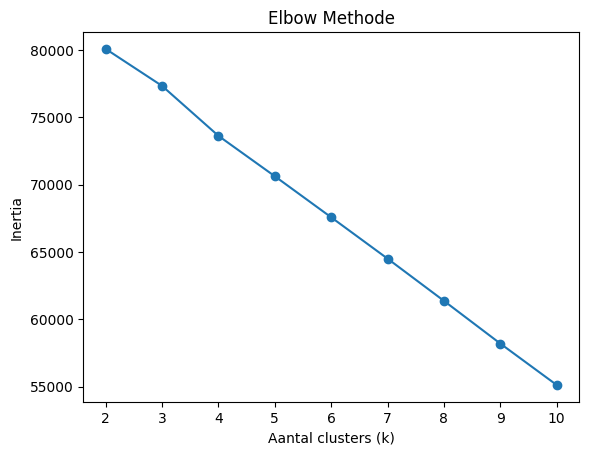

In [8]:
# Elbow methode voor beste k
features = ['Gr Liv Area', 'Overall Qual', 'Neighborhood']  # Kies vaste feature set
data = pd.get_dummies(df[features], drop_first=True)  # Encode categorische variabele
scaled = StandardScaler().fit_transform(data)  # Schaal data

inertias = []  # Opslag inertia waarden
K_range = range(2, 11)  # Test k van 2 t/m 10

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)  # Initialiseer model
    model.fit(scaled)  # Train model
    inertias.append(model.inertia_)  # Sla inertia op

plt.plot(K_range, inertias, marker='o')  # Plot grafiek
plt.xlabel('Aantal clusters (k)')  # X-as label
plt.ylabel('Inertia')  # Y-as label
plt.title('Elbow Methode')  # Titel
plt.show()  # Toon plot

In [ ]:
# Reduceer de geschaalde data naar 2 dimensies
pca = PCA(n_components=2)  
X_pca = pca.fit_transform(X_scaled)  

# Maak visualisatie
plt.figure(figsize=(8,6))  
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis", alpha=0.6)  

# Titel toevoegen
plt.title("Cluster Visualisatie met PCA (2D projectie)")  

# Label assen
plt.xlabel("PCA Component 1")  
plt.ylabel("PCA Component 2")  

# Toon plot
plt.show()

In [ ]:
# Bereken silhouette score per datapunt
sample_silhouette_values = silhouette_samples(X_scaled, clusters)  

# Aantal clusters ophalen
n_clusters = len(np.unique(clusters))  

# Startpositie voor plot
y_lower = 10  

# Maak figuur
plt.figure(figsize=(8,6))  

# Loop door elke cluster
for i in range(n_clusters):  
    cluster_silhouette_values = sample_silhouette_values[clusters == i]  
    cluster_silhouette_values.sort()  
    
    size_cluster = cluster_silhouette_values.shape[0]  
    y_upper = y_lower + size_cluster  
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),  
                      0,  
                      cluster_silhouette_values)  
    
    y_lower = y_upper + 10  

# Verticale lijn voor gemiddelde silhouette score
plt.axvline(x=silhouette_score(X_scaled, clusters), color="red", linestyle="--")  

# Titel en labels
plt.title("Silhouette Plot per Cluster")  
plt.xlabel("Silhouette coefficient values")  
plt.ylabel("Cluster")  

# Toon plot
plt.show()

## Reflectie 
- Experiment 1 was de baseline.
- Verhogen van k liet zien dat silhouette soms daalde.
- Toevoegen van YearBuilt verbeterde scheiding.
- Beste configuratie werd gekozen op basis van hoogste silhouette score.
- Elbow-methode hielp bij bepalen logisch aantal clusters.

Conclusie: Feature-keuze had grotere impact dan alleen verhogen van k.